# Tutorial: GNN Implementation

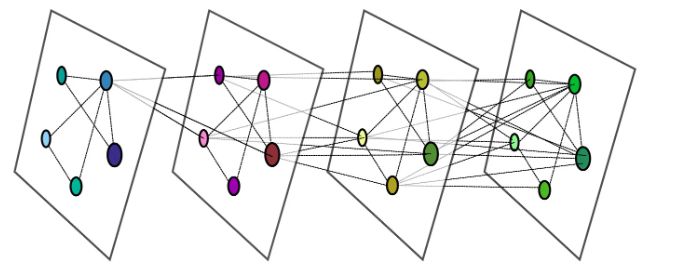


## 1. Why do we need Graph Neural Networks?

Most models you have met so far expect their input to have a **fixed, regular shape**:

- an **MLP** expects a fixed-length vector,
- a **CNN** expects a grid of pixels (every pixel has the same number of neighbours, arranged the same way),
- an **RNN / LSTM** expects an ordered sequence (word 1, word 2, ...).

But a huge amount of real-world data is **not** a vector, a grid, or a sequence. It is a **graph**: a set of *objects* (nodes) joined by *relationships* (edges).

| Domain | Node | Edge |
|---|---|---|
| Social network | a person | "are friends / interacted" |
| Molecule | an atom | a chemical bond |
| Road map | an intersection | a road |
| Recommender system | a user or item | "bought / clicked" |
| Knowledge graph | a concept | a relation |


**GNNs'  definition:** A Graph Neural Network (GNN) is a class of artificial intelligence models designed to process data structured as networks or graphs. Instead of traditional data (like images or text), GNNs analyze interconnected relationships where objects are nodes (e.g., users in a social network, atoms in a molecule) and their relationships are edges.


In [1]:
import os
import torch
os.environ['TORCH'] = torch.__version__
print(torch.__version__)

!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q pyg-lib -f https://data.pyg.org/whl/nightly/torch-${TORCH}.html
!pip install -q git+https://github.com/pyg-team/pytorch_geometric.git

2.11.0+cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 105.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 71.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 65.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import torch.nn.functional as F
import torch.nn as nn
from torch_geometric.data import DataLoader, Data
from torch_geometric.nn import GCNConv, global_mean_pool
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import random

## 2. Notation

A graph is written $G = (V, E)$:

- $V$ is the set of **nodes** (also called *vertices*); we write $N = |V|$ for the number of nodes.
- $E$ is the set of **edges**; an edge $(u,v) \in E$ means node $u$ is connected to node $v$.
- $\mathcal{N}(v) = \{\, u : (u,v)\in E \,\}$ is the **neighbourhood** of $v$ - the nodes directly connected to it.
- $d_v = |\mathcal{N}(v)|$ is the **degree** of $v$ (how many neighbours it has).

We store the structure and the data in matrices:

- **Adjacency matrix** $\mathbf{A} \in \mathbb{R}^{N\times N}$: $A_{uv}=1$ if $(u,v)\in E$, else $0$. (For an undirected graph $\mathbf{A}$ is symmetric.)
- **Degree matrix** $\mathbf{D}$: a diagonal matrix with $D_{vv} = d_v$.
- **Feature matrix** $\mathbf{X} \in \mathbb{R}^{N\times F}$: row $v$ is the feature vector $\mathbf{x}_v$ of node $v$ ($F$ features per node).

### Regular data vs. graph data



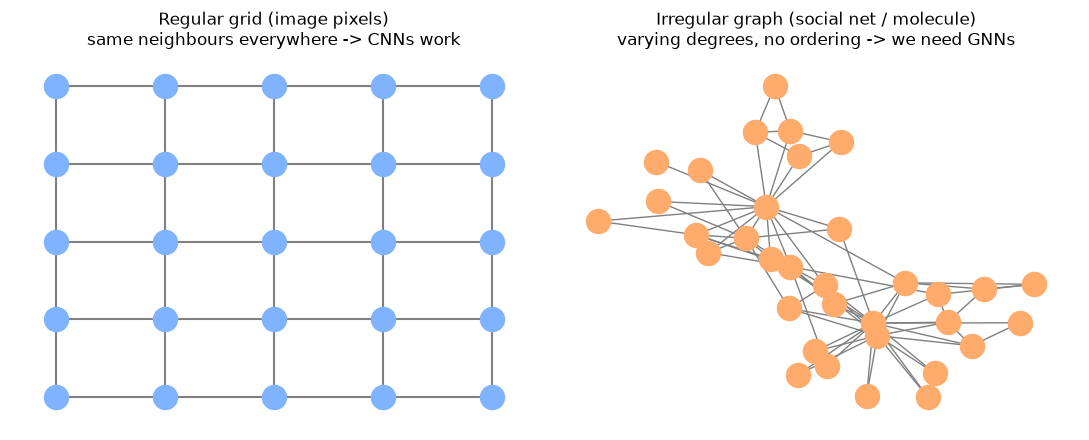

In [3]:
# Figure: regular grid data (where CNNs work) vs. irregular graph data (where GNNs are needed)
import networkx as nx
import matplotlib.pyplot as plt

Recall that learning tasks on GNNs can be largely classified into:
  * Node/edge Prediction
  * (Sub)graph Prediction


First, we'll start with node prediction. We're going to load a very small and simple social network graph as our dataset, the Karate Club Graph.

In this graph, each node represents a person and they are labeled 1 or 0 depending on who their instructor is. Two nodes are connected if the people they represent have interacted before.

Since our task is node classification, we're going to be splitting the nodes in this graph into our training set and our testing set.

In [4]:
#############################
# Data Preparation & Visualization (Karate Club Graph)
#############################

def prepare_karate_data():
    # Load the Karate Club graph using NetworkX.
    G = nx.karate_club_graph()
    num_nodes = G.number_of_nodes()

    # Create labels and colors for visualization based on club membership.
    club_map = {'Mr. Hi': 0, 'Officer': 1}
    labels = []
    colors = []
    for i in range(num_nodes):
        club = G.nodes[i].get('club', 'Mr. Hi')
        labels.append(club_map.get(club, 0))
        colors.append('lightblue' if club_map.get(club, 0) == 0 else 'lightgreen')

    # Plot the graph.
    plt.figure(figsize=(5, 5))
    nx.draw_networkx(G, node_color=colors, with_labels=True)
    plt.title("Karate Club Graph")
    plt.show()

    # Use an identity matrix as node features (each node gets a one-hot feature vector).
    x = torch.eye(num_nodes, dtype=torch.float)

    # Convert graph edges to PyG's edge_index format.
    edge_index = torch.tensor(list(G.edges), dtype=torch.long).t().contiguous()
    # Since the graph is undirected, add reverse edges.
    edge_index = torch.cat([edge_index, edge_index[[1, 0]]], dim=1)

    data = Data(x=x, edge_index=edge_index, y=torch.tensor(labels, dtype=torch.long))
    data = split_data(data, train_ratio=0.8)  # Split into training and test sets.
    return data

def split_data(data, train_ratio=0.8):
    """
    Splits the node data into train and test sets.
    Args:
        data (Data): PyG Data object.
        train_ratio (float): Proportion of nodes used for training.
    Returns:
        Data: The same data object with added train_mask and test_mask.
    """
    num_nodes = data.num_nodes
    indices = torch.randperm(num_nodes)
    train_count = int(train_ratio * num_nodes)
    train_idx = indices[:train_count]
    test_idx = indices[train_count:]

    train_mask = torch.zeros(num_nodes, dtype=torch.bool)
    test_mask = torch.zeros(num_nodes, dtype=torch.bool)
    train_mask[train_idx] = True
    test_mask[test_idx] = True

    data.train_mask = train_mask
    data.test_mask = test_mask
    return data

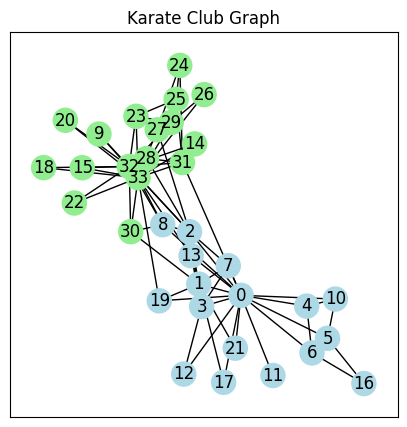

In [5]:
data = prepare_karate_data()

## 3. Message passing

A GNN builds a representation (an "embedding") $\mathbf{h}_v$ for each node by repeating a simple two-step ritual over several **layers** (also called *hops*). At layer $k$, every node:

1. **AGGREGATES** a summary of the messages coming from its neighbours, then
2. **UPDATES** its own state using that summary.

Formally, starting from $\mathbf{h}_v^{(0)} = \mathbf{x}_v$:

$$
\mathbf{h}_v^{(k)} \;=\; \underbrace{\phi^{(k)}}_{\text{UPDATE}}\!\Big(\;\mathbf{h}_v^{(k-1)},\;\; \underbrace{\bigoplus_{u\in\mathcal{N}(v)}}_{\text{AGGREGATE}} \; \psi^{(k)}\big(\mathbf{h}_v^{(k-1)},\,\mathbf{h}_u^{(k-1)}\big)\Big)
$$

- $\psi^{(k)}$ is the **message** function (what a neighbour sends).
- $\bigoplus$ is a **permutation-invariant** aggregator  ( e.g., **sum, mean, or max**). This is the crucial ingredient: because sum / mean / max ignore the order of their inputs, relabelling the neighbours cannot change the result. *This is how a GNN stays permutation invariant.*
- $\phi^{(k)}$ is the **update** function (usually a small neural net + a nonlinearity).

**Intuition:** Think of each node as a person who, every round, listens to all their friends and updates their opinion.
- After **1 layer**, a node knows about itself and its immediate neighbours (**1-hop**).
- After **2 layers**, it indirectly hears from neighbours-of-neighbours (**2-hop**), and so on.
- After $k$ layers, each node's embedding summarises its whole **$k$-hop neighbourhood**.

Almost every GNN you will ever meet, GCN, GraphSAGE, GAT, GIN, is just a specific choice of $\psi$, $\bigoplus$, and $\phi$.* Run the next cell to see one round of message passing for a single node.


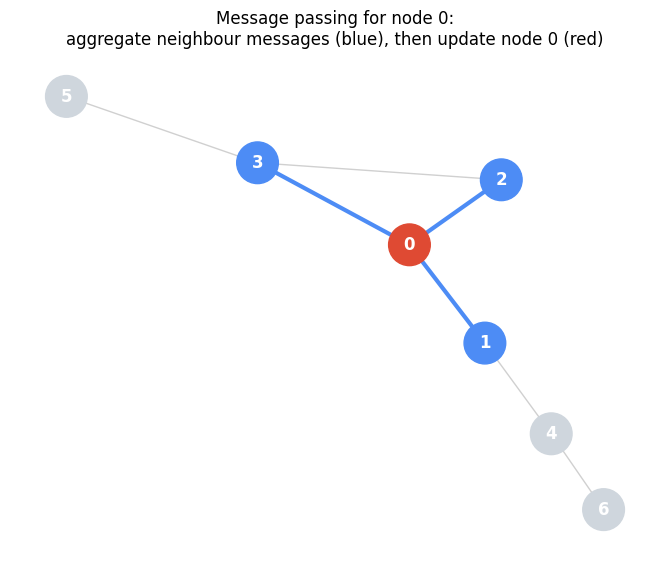

In [6]:
# Figure: one round of message passing. Node 0 (red) updates itself by aggregating
# messages from its direct neighbours (blue). Grey nodes are not involved in THIS update.
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
G.add_edges_from([(0, 1), (0, 2), (0, 3), (1, 4), (2, 3), (3, 5), (4, 6)])
pos = nx.spring_layout(G, seed=3)

target = 0
neighbors = set(G.neighbors(target))

node_colors = []
for n in G.nodes():
    if n == target:
        node_colors.append("#df4a33")     # the node being updated
    elif n in neighbors:
        node_colors.append('#4d8cf5')     # its 1-hop neighbours (the senders)
    else:
        node_colors.append('#cfd6dd')     # everyone else

edge_colors = ['#4d8cf5' if target in e else '#d0d0d0' for e in G.edges()]
edge_widths = [3.0 if target in e else 1.0 for e in G.edges()]

plt.figure(figsize=(6.5, 5))
nx.draw(G, pos, node_color=node_colors, edge_color=edge_colors, width=edge_widths,
        node_size=900, with_labels=True, font_weight='bold', font_color='white')
plt.title("Message passing for node 0:\naggregate neighbour messages (blue), then update node 0 (red)")
plt.show()


## 4. GNN layer

We now implement a GNN layer that directly instantiates the **message-passing recipe from Section 3**. We use the simplest useful aggregator - the **mean** of a node's neighbours - together with a small but important twist popularised by **GraphSAGE** (Hamilton et al., 2017): transform a node's *own* features and its *neighbour summary* with **two separate weight matrices**, then add them.

Why the separate self-weight? Because if a node only ever replaced itself with the average of its neighbours, it would quickly *forget who it is*. Keeping its own features on their own channel lets each node listen to its neighbourhood **without losing its identity**.


### The GNN layer, term by term (mean aggregation)

One layer turns node features $\mathbf{h}_v^{(l)}$ into $\mathbf{h}_v^{(l+1)}$ with the update:

$$
\boxed{\;\mathbf{h}_v^{(l+1)} \;=\; \sigma\!\Big(\, \mathbf{W}_{\text{self}}\,\mathbf{h}_v^{(l)} \;+\; \mathbf{W}_{\text{neigh}}\cdot \underbrace{\frac{1}{|\mathcal{N}(v)|}\sum_{u\in\mathcal{N}(v)}\mathbf{h}_u^{(l)}}_{\text{mean of the neighbours}} \Big)\;}
$$

This is exactly the **AGGREGATE -> UPDATE** pattern from Section 3:

| Piece | Name | What it does |
|---|---|---|
| $\frac{1}{\lvert\mathcal N(v)\rvert}\sum_{u\in\mathcal N(v)}\mathbf h_u$ | **AGGREGATE** (mean) | summarise the neighbourhood into one vector |
| $\mathbf{W}_{\text{neigh}}$ | learnable weights | transform that neighbour summary |
| $\mathbf{W}_{\text{self}}$ | learnable weights | transform the node's own features (keeps its identity) |
| $+$ then $\sigma$ | **UPDATE** | combine self + neighbours, then a nonlinearity (ReLU) |




### One message-passing toy example

Before we train anything, let's make the "aggregate the neighbours" idea completely concrete. The cell below builds a tiny 4-node graph, gives each node a single number as its feature, and computes the **mean of each node's neighbours** in one step - exactly the AGGREGATE part of our GNN layer.


In [7]:
# A tiny by-hand example of ONE message-passing step (mean aggregation).
# Graph edges (undirected):  0-1, 0-2, 1-2, 2-3
# Each node's feature is just a single number.
import torch

# edge_index lists BOTH directions of every undirected edge (row -> col = source -> target)
edge_index = torch.tensor([[0, 1, 0, 2, 1, 2, 2, 3],
                           [1, 0, 2, 0, 2, 1, 3, 2]], dtype=torch.long)
x = torch.tensor([[10.], [20.], [30.], [40.]])   # node features
N = x.size(0)
row, col = edge_index

# AGGREGATE: mean of each node's neighbour features
deg = torch.zeros(N)
deg.scatter_add_(0, col, torch.ones_like(col, dtype=x.dtype))   # how many neighbours each node has
neigh_sum = torch.zeros_like(x).index_add(0, col, x[row])       # sum the neighbour features
neigh_mean = neigh_sum / deg.clamp(min=1).unsqueeze(1)          # -> mean

print("node | own feature | neighbours | mean(neighbours)")
for v in range(N):
    nbrs = row[col == v].tolist()
    print(f"  {v}  |     {x[v].item():4.0f}    | {nbrs}      -> {neigh_mean[v].item():5.1f}")


node | own feature | neighbours | mean(neighbours)
  0  |       10    | [1, 2]      ->  25.0
  1  |       20    | [0, 2]      ->  20.0
  2  |       30    | [0, 1, 3]      ->  23.3
  3  |       40    | [2]      ->  30.0


In [8]:
#############################
# General GNN Layer (message passing with MEAN aggregation, GraphSAGE-style)
#############################
class GNNLayer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(GNNLayer, self).__init__()
        # Two separate learnable transforms:
        #   lin_self  -> the node's OWN features
        #   lin_neigh -> the aggregated NEIGHBOUR summary
        # Keeping them separate lets a node preserve its identity while still
        # listening to its neighbours (the key idea of GraphSAGE).
        self.lin_self = nn.Linear(in_channels, out_channels, bias=True)
        self.lin_neigh = nn.Linear(in_channels, out_channels, bias=False) #Neighbor transformation
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.lin_self.weight)
        nn.init.xavier_uniform_(self.lin_neigh.weight)
        nn.init.zeros_(self.lin_self.bias)

    def forward(self, x, edge_index):
        """
        Args:
            x (Tensor): Node features of shape [N, in_channels].
            edge_index (LongTensor): Graph connectivity with shape [2, E]
                                     (a message travels from row -> col).

        Returns:
            Tensor: Updated node features of shape [N, out_channels].
        """
        num_nodes = x.size(0)
        row, col = edge_index

        # ---- 1. AGGREGATE: average each node's neighbour features ----
        deg = torch.zeros(num_nodes, device=x.device)
        deg.scatter_add_(0, col, torch.ones_like(col, dtype=x.dtype))
        deg = deg.clamp(min=1)                              # isolated nodes -> avoid /0

        neigh_sum = torch.zeros_like(x)
        neigh_sum = neigh_sum.index_add(0, col, x[row])     # sum neighbour features into targets
        neigh_mean = neigh_sum / deg.unsqueeze(1)           # -> MEAN aggregation

        # ---- 2. UPDATE: combine the node's own features with the neighbour summary ----
        out = self.lin_self(x) + self.lin_neigh(neigh_mean)
        return out


#############################
# Node Classification Model using GNNLayer
#############################
class NodeClassifier(nn.Module):

    def __init__(self, in_channels, hidden_channels, num_classes, num_layers=2):
        super(NodeClassifier, self).__init__()
        self.num_layers = num_layers
        self.convs = nn.ModuleList()

        if num_layers == 1:
            self.convs.append(GNNLayer(in_channels, num_classes))
        else:
            self.convs.append(GNNLayer(in_channels, hidden_channels))
            for _ in range(num_layers - 2):
                self.convs.append(GNNLayer(hidden_channels, hidden_channels))
            self.convs.append(GNNLayer(hidden_channels, num_classes))

    def forward(self, data, return_hidden=False):
        x, edge_index = data.x, data.edge_index               #data.edge_index.shape = [2, E]
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i != len(self.convs) - 1:
                x = F.relu(x)
        if return_hidden:
            return x
        return x


In [9]:
def train_node_classifier(data, model, epochs=10, lr=0.01):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        out = model(data)
        loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()
        if (epoch+1) % 1 == 0:
            pred = out.argmax(dim=1)
            correct = int((pred == data.y).sum())
            acc = correct / data.num_nodes
            print(f"Epoch {epoch+1:3d}: Loss {loss.item():.4f}, Training Acc {acc:.4f}")

def evaluate_node_classifier(data, model, mask='test'):
    model.eval()
    with torch.no_grad():
        out = model(data)
        if mask == 'train':
            pred = out[data.train_mask].argmax(dim=1)
            correct = (pred == data.y[data.train_mask]).sum().item()
            return correct / data.train_mask.sum().item()
        else:
            pred = out[data.test_mask].argmax(dim=1)
            correct = (pred == data.y[data.test_mask]).sum().item()
            return correct / data.test_mask.sum().item()

In [10]:
# Run node classification example
model = NodeClassifier(in_channels=data.num_node_features, hidden_channels=16, num_classes=2, num_layers=2)
train_node_classifier(data, model)

Epoch   1: Loss 0.6525, Training Acc 0.6765
Epoch   2: Loss 0.6015, Training Acc 0.7059
Epoch   3: Loss 0.5550, Training Acc 0.8235
Epoch   4: Loss 0.5106, Training Acc 0.8529
Epoch   5: Loss 0.4678, Training Acc 0.8824
Epoch   6: Loss 0.4272, Training Acc 0.8824
Epoch   7: Loss 0.3882, Training Acc 0.9706
Epoch   8: Loss 0.3502, Training Acc 0.9706
Epoch   9: Loss 0.3140, Training Acc 0.9706
Epoch  10: Loss 0.2800, Training Acc 0.9706


In [11]:
test_acc = evaluate_node_classifier(data, model, mask='test')
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 1.0000


### Oversmoothing Example

Sometimes in other architectures (CNNs in particular), more layers generally mean better performance.

However, in GNNs, this may not be the case due to oversmoothing.

## 5. oversmoothing

With CNNs, increasing the number of layers often improves performance. In contrast, making a GNN too deep can actually **degrade** its performance. This phenomenon is known as **oversmoothing**.

Recall that each GNN layer updates a node's representation by combining information from its neighbours (and usually from the node itself). This aggregation behaves like a **smoothing** or **blurring** operation. After one layer, neighbouring nodes become slightly more similar. As more layers are stacked, this smoothing accumulates across the entire $k$-hop neighbourhood, making node representations increasingly alike.

**Average pairwise cosine similarity** between node embeddings:
$$
\cos(\mathbf{h}_i,\mathbf{h}_j)=\frac{\mathbf{h}_i\cdot\mathbf{h}_j}{\lVert\mathbf{h}_i\rVert\,\lVert\mathbf{h}_j\rVert}.
$$
A value close to **0** indicates that the node embeddings point in different directions, meaning the nodes remain distinguishable . In contrast, a value close to **1** indicates that the embeddings have become nearly identical, which is a sign of **oversmoothing**. As the number of GNN layers increases, observe how this value gradually approaches **1**.


In [12]:
#############################
# Utility Function to Compute Average Pairwise Cosine Similarity
#############################
def compute_average_cosine_similarity(embeddings):
    """
    Computes the average pairwise cosine similarity between node embeddings.
    A high average similarity indicates that node representations are very alike
    (i.e., oversmoothing has occurred).

    Args:
        embeddings (Tensor): Node embeddings of shape [num_nodes, features].

    Returns:
        float: Average pairwise cosine similarity (excluding self-similarity).
    """
    # Normalize embeddings.
    norm_embeddings = F.normalize(embeddings, p=2, dim=1)
    # Compute cosine similarity matrix.
    sim_matrix = torch.matmul(norm_embeddings, norm_embeddings.t())
    num_nodes = sim_matrix.size(0)
    # Exclude self-similarity by masking the diagonal.
    mask = torch.eye(num_nodes, device=sim_matrix.device).bool()
    avg_sim = sim_matrix[~mask].mean().item()
    return avg_sim

In [13]:
for num_layers in [2, 4, 8, 16]:
    print(f"\nTraining model with {num_layers} GNN layers:")
    model = NodeClassifier(in_channels=data.num_node_features,
                            hidden_channels=16,
                            num_classes=2,
                            num_layers=num_layers)
    train_node_classifier(data, model, epochs=10, lr=0.01)

    # After training, obtain the final node embeddings.
    model.eval()
    with torch.no_grad():
        embeddings = model(data, return_hidden=True)
    avg_sim = compute_average_cosine_similarity(embeddings)
    print(f"Average pairwise cosine similarity of final embeddings: {avg_sim:.4f}")
    # A higher similarity (closer to 1.0) is indicative of oversmoothing.



Training model with 2 GNN layers:
Epoch   1: Loss 0.7017, Training Acc 0.5000
Epoch   2: Loss 0.6619, Training Acc 0.5294
Epoch   3: Loss 0.6236, Training Acc 0.6471
Epoch   4: Loss 0.5866, Training Acc 0.6471
Epoch   5: Loss 0.5504, Training Acc 0.7059
Epoch   6: Loss 0.5151, Training Acc 0.7941
Epoch   7: Loss 0.4801, Training Acc 0.8824
Epoch   8: Loss 0.4455, Training Acc 0.9118
Epoch   9: Loss 0.4115, Training Acc 0.9118
Epoch  10: Loss 0.3780, Training Acc 0.9412
Average pairwise cosine similarity of final embeddings: 0.1164

Training model with 4 GNN layers:
Epoch   1: Loss 0.6680, Training Acc 0.4706
Epoch   2: Loss 0.5690, Training Acc 0.8824
Epoch   3: Loss 0.4721, Training Acc 0.9118
Epoch   4: Loss 0.3890, Training Acc 0.9412
Epoch   5: Loss 0.3016, Training Acc 0.9412
Epoch   6: Loss 0.2211, Training Acc 0.9706
Epoch   7: Loss 0.1540, Training Acc 0.9706
Epoch   8: Loss 0.1039, Training Acc 1.0000
Epoch   9: Loss 0.0685, Training Acc 1.0000
Epoch  10: Loss 0.0456, Trainin

As GNNs get deeper, they may begin to generate the same embeddings for all nodes since their k-hop neighbours are the same.

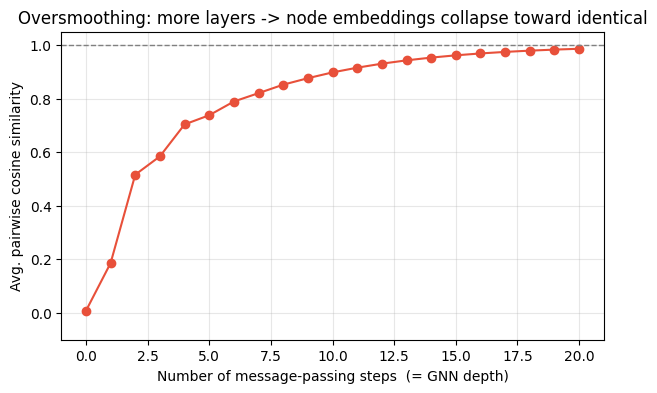

In [14]:
# Demonstration: oversmoothing needs NO training. We repeatedly apply MEAN neighbour
# aggregation (with a self term) to random node features and watch every embedding
# collapse toward the same vector (average cosine similarity -> 1).
import torch
import networkx as nx
import matplotlib.pyplot as plt

G = nx.karate_club_graph()
N = G.number_of_nodes()

A = torch.tensor(nx.to_numpy_array(G), dtype=torch.float) + torch.eye(N)  # include a self term
P = A / A.sum(dim=1, keepdim=True)          # row-normalised = mean aggregation

def avg_pairwise_cosine(H):
    Hn = torch.nn.functional.normalize(H, p=2, dim=1)
    S = Hn @ Hn.t()
    off_diag = ~torch.eye(N, dtype=torch.bool)
    return S[off_diag].mean().item()

torch.manual_seed(0)
H = torch.randn(N, 8)                        # random starting features (no learning at all)
sims = [avg_pairwise_cosine(H)]
for _ in range(20):
    H = P @ H                                # one GNN-style mean-aggregation step (= one "layer")
    sims.append(avg_pairwise_cosine(H))

plt.figure(figsize=(7, 4))
plt.plot(range(len(sims)), sims, marker='o', color='#e8503a')
plt.axhline(1.0, ls='--', color='gray', lw=1)
plt.xlabel("Number of message-passing steps  (= GNN depth)")
plt.ylabel("Avg. pairwise cosine similarity")
plt.title("Oversmoothing: more layers -> node embeddings collapse toward identical")
plt.ylim(-0.1, 1.05)
plt.grid(alpha=0.3)
plt.show()


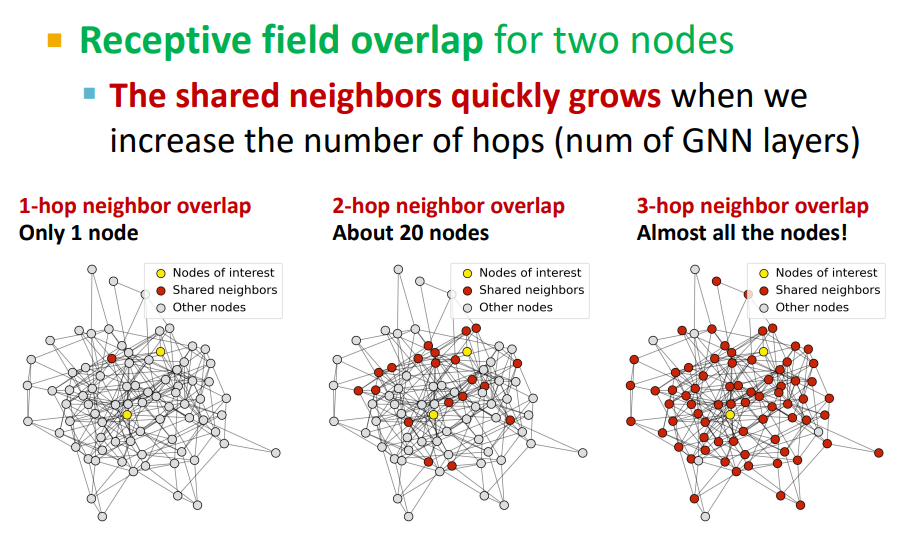



---


### Graph Classification

Now, we're going to be going over a graph prediction (quite similar to node prediction) problem on the MUTAG dataset.

The MUTAG dataset is a widely used benchmark in graph classification.
It consists of 188 graphs, each representing a chemical compound.
The label of each graph indicates whether the compound is mutagenic on
Salmonella typhimurium (1 for mutagenic, 0 for non-mutagenic).

Each node in a graph represents an atom and comes with a feature vector
that represents what type of atom it is (via one one encoding).

MUTAG Dataset Info:
  Number of graphs: 188
  Number of classes: 2
  Number of node features: 7

Sample Graph Data:
Data(edge_index=[2, 38], x=[17, 7], edge_attr=[38, 4], y=[1])

Sample Node Features:
tensor([[1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0.]])


Processing...
Done!


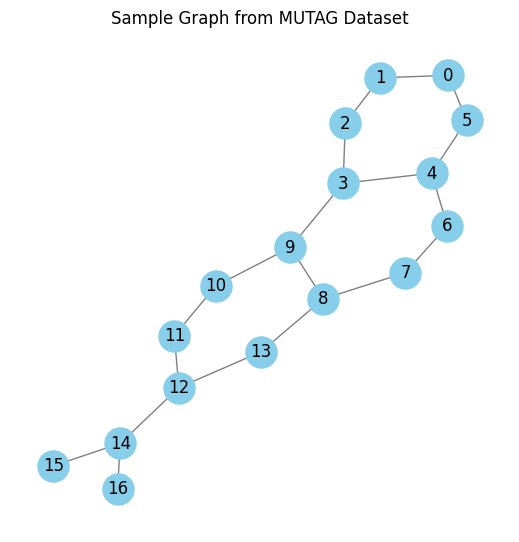

In [15]:
from torch_geometric.datasets import TUDataset

###############################################
# MUTAG Dataset
###############################################

# Load the dataset
dataset = TUDataset(root='data/TUDataset', name='MUTAG')

print("MUTAG Dataset Info:")
print(f"  Number of graphs: {len(dataset)}")
print(f"  Number of classes: {dataset.num_classes}")
print(f"  Number of node features: {dataset.num_node_features}")

# Inspect a sample graph
sample_data = dataset[0]
print("\nSample Graph Data:")
print(sample_data)
print("\nSample Node Features:")
print(sample_data.x)

# Visualize the connectivity of the sample graph using NetworkX.
G = nx.Graph()
edges = sample_data.edge_index.t().tolist()
G.add_edges_from(edges)

plt.figure(figsize=(5, 5))
nx.draw(G, with_labels=True, node_color='skyblue', node_size=500, edge_color='gray')
plt.title("Sample Graph from MUTAG Dataset")
plt.show()



---
We already have a model that generates embeddings for each node in the graph.

To obtain a graph-level representation, we can use graph pooling, which aggregates these node embeddings into a single, fixed-size vector. This is can be achieved by operations such as summing, averaging, or taking the maximum of the node features, thereby transforming variable-size node-level information into a consistent graph-level embedding.

In this tutorial, we use the straightforward approach of global mean pooling.

## 6. Whole-graph prediction:

So far every layer produces one embedding **per node**. But for the MUTAG task we must label the **entire graph** (is this molecule mutagenic?), so we need a single vector for the whole graph.

A **readout** (or **pooling**) function collapses the set of node embeddings $\{\mathbf{h}_v : v\in V\}$ into one fixed-size graph embedding $\mathbf{h}_G$. Because a graph has no natural node ordering, the readout - just like the neighbour aggregator - **must be permutation invariant**. The three standard choices:

$$
\text{mean:}\;\; \mathbf{h}_G=\frac{1}{|V|}\sum_{v\in V}\mathbf{h}_v,\qquad
\text{sum:}\;\; \mathbf{h}_G=\sum_{v\in V}\mathbf{h}_v,\qquad
\text{max:}\;\; \mathbf{h}_G=\max_{v\in V}\mathbf{h}_v .
$$




In [16]:
###############################################
# Graph Classification Model
###############################################
class GraphClassifier(nn.Module):
    def __init__(self, in_channels, hidden_channels, num_classes, num_layers=2):
        """
        A graph classification model using our custom GNN layers.
        """
        super(GraphClassifier, self).__init__()
        self.num_layers = num_layers
        self.convs = nn.ModuleList()

        if num_layers == 1:
            self.convs.append(GNNLayer(in_channels, num_classes))
        else:
            # First layer: input -> hidden.
            self.convs.append(GNNLayer(in_channels, hidden_channels))
            # Middle layers (if any): hidden -> hidden.
            for _ in range(num_layers - 2):
                self.convs.append(GNNLayer(hidden_channels, hidden_channels))
            # Final layer: hidden -> num_classes.
            self.convs.append(GNNLayer(hidden_channels, num_classes))

    def forward(self, data):
        """
        Args:
            data: A data object with attributes:
                  - x: Node features (Tensor of shape [N, F]).
                  - edge_index: Edge indices (Tensor of shape [2, E]).
                  - y: Graph label (Tensor with a single value).
        Returns:
            Tensor: Graph-level output (logits) with shape [num_classes].
        """
        x, edge_index = data.x, data.edge_index
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i != len(self.convs) - 1:
                x = F.relu(x)
        # Global mean pooling: average node embeddings to obtain a graph-level embedding.
        graph_embedding = x.mean(dim=0)
        return graph_embedding

###############################################
# Training and Evaluation Functions
###############################################
def train(model, dataset, optimizer, device):
    model.train()
    total_loss = 0.0
    for data in dataset:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data)
        loss = F.cross_entropy(out.unsqueeze(0), data.y.view(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataset)

def test(model, dataset, device):
    model.eval()
    correct = 0
    for data in dataset:
        data = data.to(device)
        with torch.no_grad():
            out = model(data)
            pred = out.argmax(dim=0)
        if pred.item() == data.y.item():
            correct += 1
    return correct / len(dataset)


In [17]:
###############################################
# Prepare Train/Test Split
###############################################
torch.manual_seed(42)
dataset = dataset.shuffle()
split_idx = int(0.8 * len(dataset))
train_dataset = dataset[:split_idx]
test_dataset = dataset[split_idx:]

In [18]:
###############################################
# Main Training Loop
###############################################
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GraphClassifier(in_channels=7, hidden_channels=64, num_classes=dataset.num_classes, num_layers=3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 100
for epoch in range(1, num_epochs + 1):
    loss = train(model, train_dataset, optimizer, device)
    train_acc = test(model, train_dataset, device)
    test_acc = test(model, test_dataset, device)
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}: Loss {loss:.4f}, Train Acc {train_acc:.4f}, Test Acc {test_acc:.4f}")

Epoch  10: Loss 0.4863, Train Acc 0.8000, Test Acc 0.7368
Epoch  20: Loss 0.4606, Train Acc 0.7933, Test Acc 0.7105
Epoch  30: Loss 0.4425, Train Acc 0.7933, Test Acc 0.7105
Epoch  40: Loss 0.4254, Train Acc 0.8200, Test Acc 0.7105
Epoch  50: Loss 0.4073, Train Acc 0.8467, Test Acc 0.6579
Epoch  60: Loss 0.3953, Train Acc 0.8533, Test Acc 0.6842
Epoch  70: Loss 0.3828, Train Acc 0.8533, Test Acc 0.7105
Epoch  80: Loss 0.3731, Train Acc 0.8600, Test Acc 0.7368
Epoch  90: Loss 0.3664, Train Acc 0.8533, Test Acc 0.7368
Epoch 100: Loss 0.3591, Train Acc 0.8600, Test Acc 0.7368


## References & further reading

**Foundational papers**
1. T. N. Kipf & M. Welling (2017). *Semi-Supervised Classification with Graph Convolutional Networks.* ICLR. https://arxiv.org/abs/1609.02907  (**the GCN**)
2. J. Gilmer, S. Schoenholz, P. Riley, O. Vinyals, G. Dahl (2017). *Neural Message Passing for Quantum Chemistry.* ICML. https://arxiv.org/abs/1704.01212  (**the message-passing framework**)
3. W. Hamilton, R. Ying, J. Leskovec (2017). *Inductive Representation Learning on Large Graphs (GraphSAGE).* NeurIPS. https://arxiv.org/abs/1706.02216
4. P. Velickovic et al. (2018). *Graph Attention Networks (GAT).* ICLR. https://arxiv.org/abs/1710.10903
5. K. Xu, W. Hu, J. Leskovec, S. Jegelka (2019). *How Powerful are Graph Neural Networks? (GIN).* ICLR. https://arxiv.org/abs/1810.00826
6. X. Bresson & T. Laurent (2017). *Residual Gated Graph ConvNets.* https://arxiv.org/abs/1711.07553
7. Q. Li, Z. Han, X.-M. Wu (2018). *Deeper Insights into Graph Convolutional Networks for Semi-Supervised Learning.* AAAI. https://arxiv.org/abs/1801.07606  (**oversmoothing**)

**Surveys, books & visual tutorials (great for students)**
8. B. Sanchez-Lengeling et al. (2021). *A Gentle Introduction to Graph Neural Networks.* Distill. https://distill.pub/2021/gnn-intro/
9. A. Daigavane et al. (2021). *Understanding Convolutions on Graphs.* Distill. https://distill.pub/2021/understanding-gnns/
10. W. L. Hamilton (2020). *Graph Representation Learning* (free book). https://www.cs.mcgill.ca/~wlh/grl_book/
11. Z. Wu et al. (2021). *A Comprehensive Survey on Graph Neural Networks.* IEEE TNNLS. https://arxiv.org/abs/1901.00596
12. M. Bronstein, J. Bruna, T. Cohen, P. Velickovic (2021). *Geometric Deep Learning: Grids, Groups, Graphs, Geodesics, and Gauges.* https://arxiv.org/abs/2104.13478

**Tools & data**
13. PyTorch Geometric documentation. https://pytorch-geometric.readthedocs.io/
14. W. W. Zachary (1977). *An Information Flow Model for Conflict and Fission in Small Groups* (the Karate Club dataset).
